In [1]:
import os
import numpy as np
import nibabel as nib
from nilearn.glm.first_level import run_glm
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.glm.first_level import compute_regressor
from nilearn.glm.first_level import run_glm
from nilearn.glm.first_level import FirstLevelModel
from nilearn.image import concat_imgs
from nilearn.plotting import plot_stat_map
import scipy
import pandas as pd
from nilearn.plotting import plot_design_matrix

In [5]:
# Define subject and runs
subject = 'Sub11'
# Path to preprocessed fMRI data
data_dir = 'N:\Experimental_Data\yujunchen\projects\LAB_IAPS_AI\preprocessed_fMRIdata\dev-sess'
onset_dir = 'F:/yujun/projects/LAB_IAPS_AI/DataRecording/' + subject + '/LogFiles/'


In [6]:
runs = ['Run01', 'Run02', 'Run03', 'Run04', 'Run05',
        'Run06', 'Run07', 'Run08', 'Run09', 'Run10']

In [7]:
# Initialize lists to store data
all_runs_data = []
all_onsets = []
all_runs_motion = []
# Loop through each run
for i, run in enumerate(runs):
    run_data = []
    # Load fMRI data
    run_dir = os.path.join(data_dir, subject, run)
    motion_param_file = [file for file in os.listdir(run_dir) if file.startswith('rp')][0]
    fmri_imgs = [f for f in os.listdir(run_dir) if f.startswith('swar')]
    # fmri_data = [nib.load(os.path.join(run_dir, file)).get_fdata() for file in fmri_img]
    for fmri_img in fmri_imgs:
        fmri_img_path = os.path.join(run_dir, fmri_img)
        fmri_data = nib.load(fmri_img_path).get_fdata()
        run_data.append(fmri_data)
    # Load onset file
    onset_file = os.path.join(onset_dir, f'spm_singletrial_{run}.csv')
    onset_data = pd.read_csv(onset_file)
    motion_df = pd.read_csv(os.path.join(run_dir, motion_param_file), header=None, sep='\s+') 
    
    # Append data to lists
    all_runs_data.append(run_data)
    all_onsets.append(onset_data)
    all_runs_motion.append(motion_df)

FileNotFoundError: [Errno 2] No such file or directory: 'F:/yujun/projects/LAB_IAPS_AI/DataRecording/Sub11/LogFiles/spm_singletrial_Run01.csv'

In [79]:
# motion
add_reg_names = ["tx", "ty", "tz", "rx", "ry", "rz"]

In [45]:
tr = 1.8  # repetition time is 1 second
n_scans = 218# the acquisition comprises 128 scans
duration = 3
frame_times = np.arange(n_scans) * tr  # here are the corresponding frame times
frame_times

array([  0. ,   1.8,   3.6,   5.4,   7.2,   9. ,  10.8,  12.6,  14.4,
        16.2,  18. ,  19.8,  21.6,  23.4,  25.2,  27. ,  28.8,  30.6,
        32.4,  34.2,  36. ,  37.8,  39.6,  41.4,  43.2,  45. ,  46.8,
        48.6,  50.4,  52.2,  54. ,  55.8,  57.6,  59.4,  61.2,  63. ,
        64.8,  66.6,  68.4,  70.2,  72. ,  73.8,  75.6,  77.4,  79.2,
        81. ,  82.8,  84.6,  86.4,  88.2,  90. ,  91.8,  93.6,  95.4,
        97.2,  99. , 100.8, 102.6, 104.4, 106.2, 108. , 109.8, 111.6,
       113.4, 115.2, 117. , 118.8, 120.6, 122.4, 124.2, 126. , 127.8,
       129.6, 131.4, 133.2, 135. , 136.8, 138.6, 140.4, 142.2, 144. ,
       145.8, 147.6, 149.4, 151.2, 153. , 154.8, 156.6, 158.4, 160.2,
       162. , 163.8, 165.6, 167.4, 169.2, 171. , 172.8, 174.6, 176.4,
       178.2, 180. , 181.8, 183.6, 185.4, 187.2, 189. , 190.8, 192.6,
       194.4, 196.2, 198. , 199.8, 201.6, 203.4, 205.2, 207. , 208.8,
       210.6, 212.4, 214.2, 216. , 217.8, 219.6, 221.4, 223.2, 225. ,
       226.8, 228.6,

In [102]:
all_onsets[0]

,Code,onsetTracking
0,2045_2.jpg,1.130336
1,6211_0.jpg,7.284512
2,5395_2.jpg,13.644960
3,3230_0.jpg,19.984040
4,2550.jpg,25.926435
5,1510_2.jpg,32.067760
6,2499.jpg,38.274384
7,3016_1.jpg,44.334610
8,2314_0.jpg,50.212306
9,4574_2.jpg,56.240375


In [109]:
# Create design matrices for each trial in each run
design_matrices = []
events = []
stim_id = 1
for run_num, onset_data in enumerate(all_onsets): #RUNS:10
    design_matrices_run = []
    event_run = []
    # Get unique stimuli (codes)
    unique_stimuli = onset_data['Code'].unique()
    # Iterate over each unique stimulus
    for stimulus in unique_stimuli: #TRIALS:60
        # Create a new DataFrame for the current stimulus
        new_onset_df = onset_data.copy()
        
        # Set condition column based on whether the stimulus matches the current iteration
        new_onset_df['condition'] = (new_onset_df['Code'] == stimulus).astype(int)
        new_onset_df['trial_type'] = new_onset_df.apply(lambda row: f'c{stim_id}' if row['condition'] == 1 else 'c0', axis=1)
        new_onset_df['onset'] = new_onset_df['onsetTracking'] 
        new_onset_df['duration'] = duration

        event = new_onset_df[['trial_type', 'onset', 'duration']]

        design_matrix = make_first_level_design_matrix(frame_times, 
                                                    event, 
                                                    add_regs=all_runs_motion[run_num].values,
                                                    add_reg_names=add_reg_names,
                                                    hrf_model='spm', 
                                                    drift_model="polynomial", 
                                                    fir_delays=[0])
        design_matrices_run.append(design_matrix)
        event_run.append(event)
        stim_id+=1
    design_matrices.append(design_matrices_run)
    events.append(event_run)


In [157]:
lss_design_matrices= []

# Loop over each run
for run_num, (fmri_file, design_matrices_run) in enumerate(zip(all_runs_data, design_matrices)):
    # Initialize list to store design matrices for LSS
    lss_design_matrices_run = []
    
    # Loop over each trial within the run
    for j, design_matrix in enumerate(design_matrices_run):
        event = events[run_num][j]  # Get event corresponding to current trial
        i_trial = 60 * run_num + j + 1  # Compute trial index
        stim_id = event['trial_type'].iloc[0]  # Get stimulus ID
        
        # Fit LSS GLM
        lss_glm = FirstLevelModel(t_r=tr,
                                  hrf_model="spm",
                                  drift_model="polynomial", 
                                  drift_order=1,
                                  noise_model='ar1',
                                  n_jobs=2
                                  )
        lss_glm.fit(fmri_file, design_matrices=design_matrix)
        lss_design_matrices_run.append(lss_glm.design_matrices_[0])

    
    # Append design matrices for the current run to the list of all design matrices
    lss_design_matrices.append(lss_design_matrices_run)



ValueError: len(run_imgs) 218 does not match len(design_matrices) 1

<AxesSubplot:label='conditions', ylabel='scan number'>

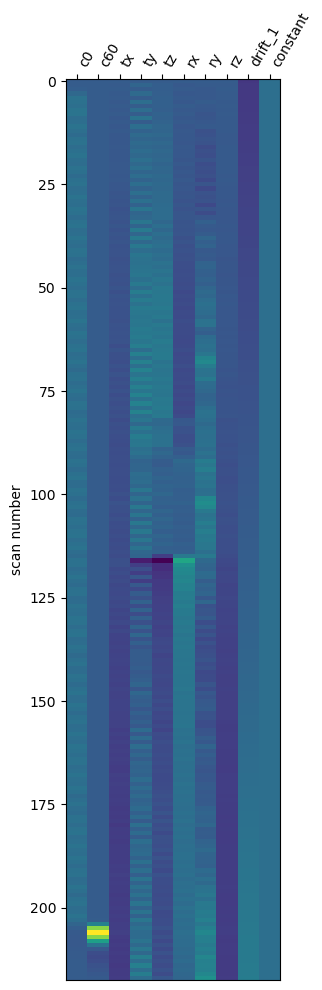

In [129]:
plot_design_matrix(design_matrices[0][-1])

Beta maps

In [85]:
len(events)

10

In [86]:
len(events[0])

60

In [112]:
events[0][-1]

,trial_type,onset,duration
0,c0,1.130336,3
1,c0,7.284512,3
2,c0,13.644960,3
3,c0,19.984040,3
4,c0,25.926435,3
5,c0,32.067760,3
6,c0,38.274384,3
7,c0,44.334610,3
8,c0,50.212306,3
9,c0,56.240375,3


In [93]:
len(all_runs_data)

10

In [92]:
len(all_runs_data[0])

218

In [143]:
len(fmri_file)

218

In [134]:
len(all_runs_data)

10

In [136]:
len(all_runs_data[0])

218

In [137]:
len(events)

10

In [138]:
len(events[0])

60

In [142]:
len(design_matrices[0][0])

218

In [146]:
len(design_matrix)

218

In [148]:
design_matrix

,c0,c1,tx,ty,tz,rx,ry,rz,drift_1,constant
0.0,0.000000,0.000000,0.000000,0.000000,7.105427e-15,-5.551115e-17,0.000000,0.000000,-0.500000,1.0
1.8,0.000000,0.000056,-0.005989,0.027841,1.660743e-02,-9.365248e-04,-0.000018,-0.000213,-0.495392,1.0
3.6,0.000000,0.044378,0.001335,-0.001198,2.084526e-02,-3.428025e-04,-0.000094,-0.000084,-0.490783,1.0
5.4,0.000000,0.298792,-0.012205,0.041595,3.134450e-02,-9.937609e-04,-0.000094,-0.000239,-0.486175,1.0
7.2,0.000000,0.565162,-0.004352,-0.001114,3.677822e-02,-4.576718e-04,-0.000079,-0.000181,-0.481567,1.0
...,...,...,...,...,...,...,...,...,...,...
383.4,-0.054735,0.000000,-0.193311,0.052496,-1.073620e-01,4.182981e-03,0.001130,-0.008341,0.481567,1.0
385.2,-0.037103,0.000000,-0.204592,0.112668,-1.358013e-01,3.085972e-03,0.001162,-0.008328,0.486175,1.0
387.0,-0.022461,0.000000,-0.190636,0.052720,-8.424599e-02,3.671174e-03,0.001131,-0.008236,0.490783,1.0
388.8,-0.012360,0.000000,-0.194615,0.101638,-1.289132e-01,3.129549e-03,0.001339,-0.008217,0.495392,1.0


In [155]:
for i in range(len(events)): #RUN:10
    fmri_file = all_runs_data[i]
    lss_design_matrices = []
    # fmri_file = all_onsets[i][2:] # start from the second scan
    for j in range(len(events[i])): #TRIAL:60
        design_matrix = design_matrices[i][j]
        lss_beta_maps = {cond: [] for cond in event["trial_type"].unique()}
        event = events[i][j]
        i_trial = 60*i+j+1
        # lss_events_df, trial_condition = lss_transformer(event, i_trial)
        # Compute and collect beta maps
        lss_glm = FirstLevelModel(t_r=tr,
                                  hrf_model="spm",
                                  drift_model="polynomial", 
                                  drift_order=1,
                                  noise_model ='ar1',
                                  n_jobs=2
                                  )
        lss_glm.fit(fmri_file, design_matrices = design_matrix)
        lss_design_matrices.append(lss_glm.design_matrices_[0])

        # beta_map = lss_glm.compute_contrast(
        #     trial_condition,
        #     output_type="effect_size",
        # )

ValueError: len(run_imgs) 218 does not match len(design_matrices) 1